<a href="https://colab.research.google.com/github/Udit587/UditVashisht-EDA-Project/blob/main/Phase1_EDA_USSeatBelts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis — Phase 1 & Phase 2
## US Seat Belts Dataset (1983–1997)

**Course: BCSE331L — Exploratory Data Analysis (TH)**

This notebook contains both Phase 1 and Phase 2 of the EDA course project, kept in a
single notebook/repository as required. It uses the **US Seat Belts** dataset, a
state-level panel dataset (50 US states + Washington DC, 1983–1997) tracking road
traffic fatality rates alongside seat-belt usage, speed-limit laws, minimum drinking-age
laws, and economic/demographic indicators.

**Phase 1 tasks (5 marks):**
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (≥ 3 visualizations)
7. Bivariate analysis (≥ 3 visualizations)
8. Multivariate analysis (≥ 3 visualizations)

**Phase 2 tasks (5 marks):**

9. 1D statistical analysis
10. 2D statistical analysis
11. 3D / N-D statistical analysis
12. K-Means clustering
13. Hierarchical clustering

---


# PHASE 1

## 0. Setup — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
REG_NO = "23BDS0172"


## 1. Loading the Dataset

The dataset is loaded directly from the raw GitHub URL so the notebook is fully
reproducible without any local file dependency.


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/USSeatBelts.csv"
df = pd.read_csv(DATA_URL)

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (765, 13)


,rownames,state,year,miles,fatalities,seatbelt,speed65,speed70,drinkage,alcohol,income,age,enforce
0,1,AK,1983,3358,0.044669,NaN,no,no,yes,no,17973,28.234966,no
1,2,AK,1984,3589,0.037336,NaN,no,no,yes,no,18093,28.343542,no
2,3,AK,1985,3840,0.033073,NaN,no,no,yes,no,18925,28.372816,no
3,4,AK,1986,4008,0.025200,NaN,no,no,yes,no,18466,28.396652,no
4,5,AK,1987,3900,0.019487,NaN,no,no,yes,no,18021,28.453251,no


In [ ]:
# Structural overview: column names, data types, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rownames    765 non-null    int64  
 1   state       765 non-null    str    
 2   year        765 non-null    int64  
 3   miles       765 non-null    int64  
 4   fatalities  765 non-null    float64
 5   seatbelt    556 non-null    float64
 6   speed65     765 non-null    str    
 7   speed70     765 non-null    str    
 8   drinkage    765 non-null    str    
 9   alcohol     765 non-null    str    
 10  income      765 non-null    int64  
 11  age         765 non-null    float64
 12  enforce     765 non-null    str    
dtypes: float64(3), int64(4), str(6)
memory usage: 77.8 KB


**Column description**

| Column | Meaning |
|---|---|
| `rownames` | Row index carried over from the source R dataset (not useful for analysis) |
| `state` | US state abbreviation (categorical) |
| `year` | Year of observation, 1983–1997 |
| `miles` | Vehicle-miles travelled in the state (millions) |
| `fatalities` | Traffic fatality rate |
| `seatbelt` | Observed seat-belt usage rate (fraction) — often missing before usage was measured |
| `speed65` / `speed70` | Whether a 65/70 mph speed limit was in force (`yes`/`no`) |
| `drinkage` | Whether the minimum legal drinking age was 21 (`yes`/`no`) |
| `alcohol` | Whether an alcohol-related law (e.g. per se law) was in effect |
| `income` | Per-capita income (USD) |
| `age` | Average age of the state's population |
| `enforce` | Type of seat-belt law enforcement: `no`, `primary`, or `secondary` |


## 2. Basic Statistical Analysis

We look at central tendency, spread, and the distribution of both numerical and
categorical variables before doing anything else, to understand the shape and scale
of the data.


In [ ]:
# Descriptive statistics for numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
rownames,765.0,383.000000,220.980768,1.000000,192.000000,383.000000,574.000000,765.000000
year,765.0,1990.000000,4.323320,1983.000000,1986.000000,1990.000000,1994.000000,1997.000000
miles,765.0,41447.734641,43961.990037,3099.000000,11401.000000,30319.000000,52312.000000,285612.000000
fatalities,765.0,0.021490,0.006171,0.008327,0.017341,0.021199,0.024774,0.045470
seatbelt,556.0,0.528852,0.170186,0.060000,0.420000,0.550000,0.650000,0.870000
income,765.0,17992.586928,4811.459296,8372.000000,14266.000000,17624.000000,21080.000000,35863.000000
age,765.0,35.137194,1.698131,28.234966,34.387501,35.391766,36.130787,39.169582


In [ ]:
# Descriptive summary for categorical columns
df.describe(include="object").T


/tmp/ipykernel_174/4099223297.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
state,765,51,AK,15
speed65,765,2,yes,494
speed70,765,2,no,711
drinkage,765,2,yes,677
alcohol,765,2,no,676
enforce,765,3,secondary,379


In [ ]:
# Unique categories for each categorical column
categorical_cols = ["state", "speed65", "speed70", "drinkage", "alcohol", "enforce"]
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].dropna().unique())}")


state: 51 unique values -> ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
speed65: 2 unique values -> ['no', 'yes']
speed70: 2 unique values -> ['no', 'yes']
drinkage: 2 unique values -> ['no', 'yes']
alcohol: 2 unique values -> ['no', 'yes']
enforce: 3 unique values -> ['no', 'primary', 'secondary']


In [ ]:
# Correlation among numeric variables (quick first look)
numeric_cols = ["miles", "fatalities", "seatbelt", "income", "age"]
df[numeric_cols].corr().round(3)


,miles,fatalities,seatbelt,income,age
miles,1.000,-0.161,0.207,0.206,0.083
fatalities,-0.161,1.000,-0.403,-0.704,-0.375
seatbelt,0.207,-0.403,1.000,0.622,0.159
income,0.206,-0.704,0.622,1.000,0.408
age,0.083,-0.375,0.159,0.408,1.000


**Observations so far:**
- `fatalities` values are small decimals (a *rate*, not a raw count), roughly in the
  0.008–0.055 range.
- `income` and `age` both trend upward across the years for most states, as expected.
- `seatbelt` has a much smaller count than the other numeric columns in `df.info()`,
  which tells us it has a substantial number of missing values — investigated next.


## 3. Handling Missing Data

### 3.1 Identify missing values


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_%", ascending=False)


,missing_count,missing_%
seatbelt,209,27.32


In [ ]:
# Visualize *where* the missingness occurs for the two affected columns, by year
missing_by_year = df.groupby("year")[["seatbelt", "speed65"]].apply(lambda x: x.isnull().mean())
missing_by_year


,seatbelt,speed65
year,,
1983,0.941176,0.0
1984,0.843137,0.0
1985,0.568627,0.0
1986,0.450980,0.0
1987,0.450980,0.0
1988,0.431373,0.0
1989,0.411765,0.0
1990,0.000000,0.0
1991,0.000000,0.0


### 3.2 Why the data is missing (Missing Data Mechanism)

The check above shows `seatbelt` is missing almost entirely in the **early years**
(1983–1987) and becomes far more complete afterwards. This is because most US states
did not have seat-belt laws — or did not measure/report usage — until the
mid-to-late 1980s. In other words, this is **not random missingness (MCAR)**; it is
**Missing At Random / structurally missing (MAR)**, tied directly to `year` and `state`.

Because of this, a single global fill value (like the overall mean) would be
misleading — it would imply a usage rate existed when it simply wasn't being tracked yet.
The more defensible approach is **group-wise imputation by state**, since seat-belt
adoption trends are state-specific and gradual over time.

`speed70` has almost no missing values and can be handled trivially. `speed65` has a
handful of missing rows following the same early-years pattern.

### 3.3 Apply imputation


In [ ]:
# Group-wise (per-state) median imputation for seatbelt.
# Using median (not mean) because seatbelt usage rates can be skewed within a state's history.
df["seatbelt"] = df.groupby("state")["seatbelt"].transform(lambda x: x.fillna(x.median()))

df["seatbelt"] = df["seatbelt"].fillna(0)

# Confirm no missing values remain
df.isnull().sum().sum()


np.int64(0)

In [ ]:
print("Missing values remaining in the dataset:", df.isnull().sum().sum())


Missing values remaining in the dataset: 0


## 4. Data Cleaning

Now that missing values are resolved, we clean up structural issues in the data:
redundant columns, duplicate rows, data types, and category label formatting.


In [ ]:
# 4.1 Drop the redundant index column carried over from the source file
df = df.drop(columns=["rownames"])

# 4.2 Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
# 4.3 Correct data types
df["year"] = df["year"].astype(int)

# Yes/no fields and enforcement type are categorical, not free text
for col in ["speed65", "speed70", "drinkage", "alcohol", "enforce", "state"]:
    df[col] = df[col].astype("category")

df.dtypes


state         category
year             int64
miles            int64
fatalities     float64
seatbelt       float64
speed65       category
speed70       category
drinkage      category
alcohol       category
income           int64
age            float64
enforce       category
dtype: object

In [ ]:
# 4.4 Sanity-check numeric ranges for implausible values (e.g. negative income, fatality rate > 1)
df[["miles", "fatalities", "seatbelt", "income", "age"]].agg(["min", "max"])


,miles,fatalities,seatbelt,income,age
min,3099,0.008327,0.06,8372,28.234966
max,285612,0.045470,0.87,35863,39.169582


No negative values, no seat-belt usage rate above 1, and no fatality rate above 1 —
the data passes basic plausibility checks. No rows need to be dropped as outliers at
this stage; extreme values look like genuine state-level variation (e.g. very high
mileage for large states like `CA`/`TX`), which we'll examine visually in the sections
below rather than removing blindly.


## 5. Data Transformation

We now engineer a few derived features that will make the upcoming visual analysis
clearer, and prepare a scaled version of the numeric features for use later in
clustering (Phase 2).


In [ ]:
# 5.1 Bin 'year' into 5-year eras, which is easier to read on plots than 15 individual years
df["year_group"] = pd.cut(
    df["year"],
    bins=[1982, 1987, 1992, 1997],
    labels=["1983-1987", "1988-1992", "1993-1997"]
)

# 5.2 Bin income into Low / Medium / High terciles for easier categorical comparison
df["income_level"] = pd.qcut(df["income"], q=3, labels=["Low", "Medium", "High"])

# 5.3 Consolidate whether *any* seat-belt enforcement law existed (binary flag)
df["has_enforcement_law"] = (df["enforce"] != "no").map({True: "yes", False: "no"})

df[["year", "year_group", "income", "income_level", "enforce", "has_enforcement_law"]].head()


,year,year_group,income,income_level,enforce,has_enforcement_law
0,1983,1983-1987,17973,Medium,no,no
1,1984,1983-1987,18093,Medium,no,no
2,1985,1983-1987,18925,Medium,no,no
3,1986,1983-1987,18466,Medium,no,no
4,1987,1983-1987,18021,Medium,no,no


In [ ]:
# 5.4 Standardize numeric features (mean 0, std 1) — this scaled version is what we will
# feed into the K-Means and Hierarchical clustering models in Phase 2, since both are
# distance-based and require comparable scales across features.
scaler = StandardScaler()
scaled_cols = ["miles", "fatalities", "seatbelt", "income", "age"]
scaled_values = scaler.fit_transform(df[scaled_cols])
scaled_df = pd.DataFrame(scaled_values, columns=[f"{c}_scaled" for c in scaled_cols], index=df.index)

df = pd.concat([df, scaled_df], axis=1)
df.head()


,state,year,miles,fatalities,seatbelt,speed65,speed70,drinkage,alcohol,income,age,enforce,year_group,income_level,has_enforcement_law,miles_scaled,fatalities_scaled,seatbelt_scaled,income_scaled,age_scaled
0,AK,1983,3358,0.044669,0.69,no,no,yes,no,17973,28.234966,no,1983-1987,Medium,no,-0.866991,3.758546,0.953251,-0.004074,-4.067261
1,AK,1984,3589,0.037336,0.69,no,no,yes,no,18093,28.343542,no,1983-1987,Medium,no,-0.861733,2.569503,0.953251,0.020883,-4.003280
2,AK,1985,3840,0.033073,0.69,no,no,yes,no,18925,28.372816,no,1983-1987,Medium,no,-0.856020,1.878209,0.953251,0.193917,-3.986030
3,AK,1986,4008,0.025200,0.69,no,no,yes,no,18466,28.396652,no,1983-1987,Medium,no,-0.852196,0.601578,0.953251,0.098457,-3.971984
4,AK,1987,3900,0.019487,0.69,no,no,yes,no,18021,28.453251,no,1983-1987,Medium,no,-0.854654,-0.324672,0.953251,0.005909,-3.938633


## 6. Univariate Analysis

Examining the distribution of individual variables of interest, one at a time.


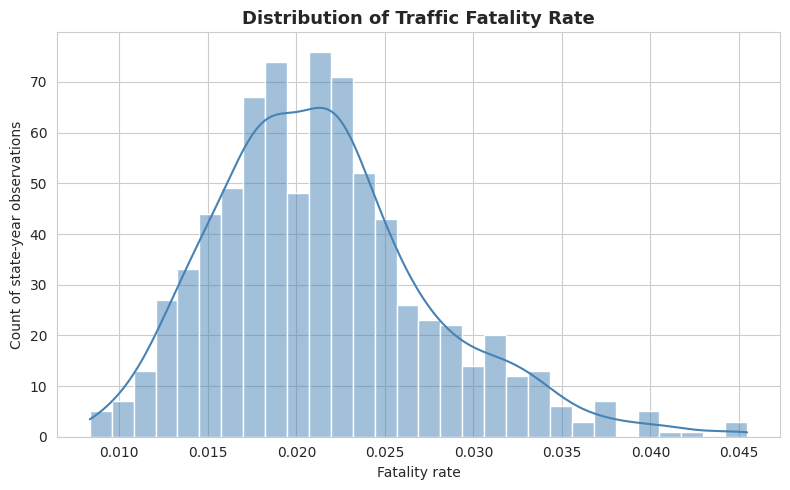

In [ ]:
# 6.1 Distribution of the fatality rate
fig, ax = plt.subplots()
sns.histplot(df["fatalities"], bins=30, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution of Traffic Fatality Rate")
ax.set_xlabel("Fatality rate")
ax.set_ylabel("Count of state-year observations")
plt.tight_layout()
plt.show()


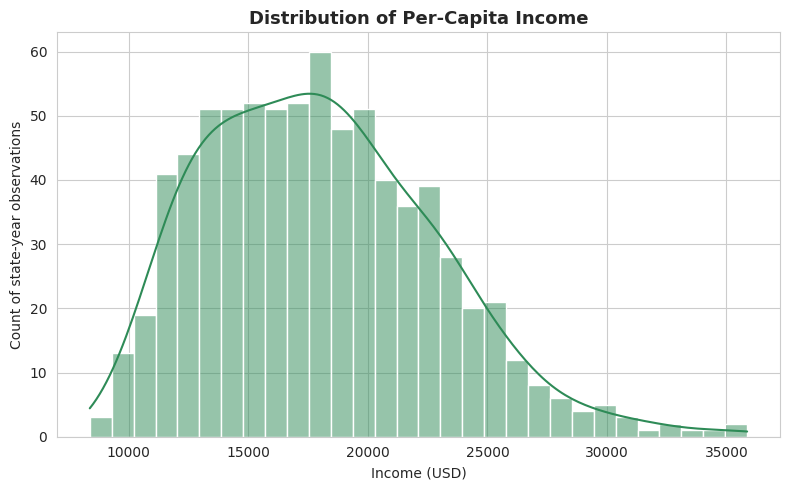

In [ ]:
# 6.2 Distribution of per-capita income
fig, ax = plt.subplots()
sns.histplot(df["income"], bins=30, kde=True, color="seagreen", ax=ax)
ax.set_title("Distribution of Per-Capita Income")
ax.set_xlabel("Income (USD)")
ax.set_ylabel("Count of state-year observations")
plt.tight_layout()
plt.show()


/tmp/ipykernel_174/155891137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="enforce", data=df, order=["no", "secondary", "primary"], palette="viridis", ax=ax)


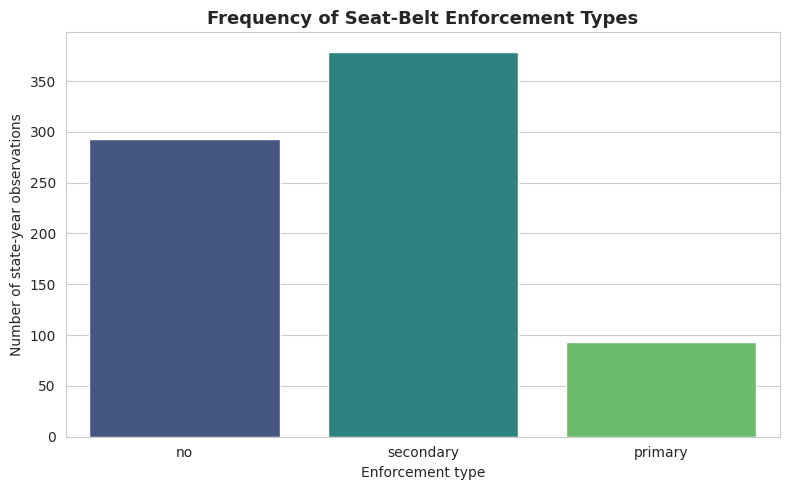

In [ ]:
# 6.3 Frequency of seat-belt law enforcement types
fig, ax = plt.subplots()
sns.countplot(x="enforce", data=df, order=["no", "secondary", "primary"], palette="viridis", ax=ax)
ax.set_title("Frequency of Seat-Belt Enforcement Types")
ax.set_xlabel("Enforcement type")
ax.set_ylabel("Number of state-year observations")
plt.tight_layout()
plt.show()


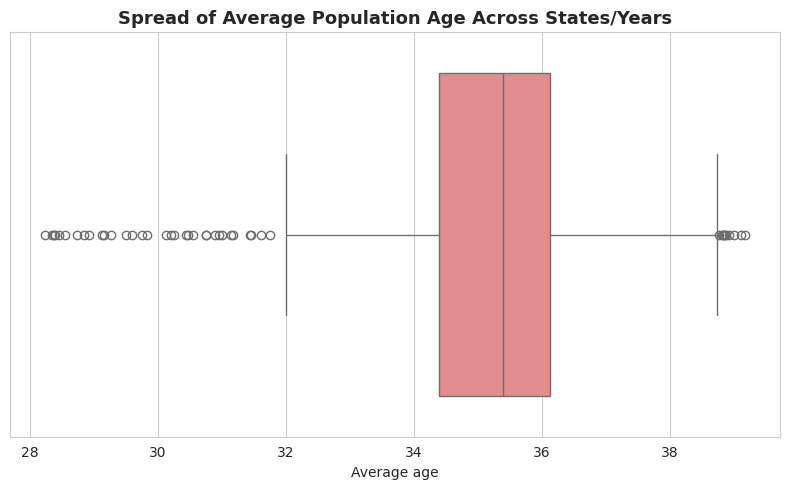

In [ ]:
# 6.4 Distribution of average population age (bonus 4th univariate plot)
fig, ax = plt.subplots()
sns.boxplot(x=df["age"], color="lightcoral", ax=ax)
ax.set_title("Spread of Average Population Age Across States/Years")
ax.set_xlabel("Average age")
plt.tight_layout()
plt.show()


**Univariate insights:**
- The fatality rate distribution is **right-skewed** — most state-years cluster at
  lower fatality rates, with a long tail of higher-fatality observations (mostly
  earlier years / less-regulated states).
- Income is also right-skewed, consistent with general income-distribution patterns
  and the fact that income rises over the 15-year study window (inflation + growth).
- `secondary` enforcement is the most common law type in this dataset, followed by
  `no` law, with `primary` enforcement being comparatively rare — reflecting that most
  US states adopted the weaker "secondary enforcement" seat-belt laws.


## 7. Bivariate Analysis

Examining the relationship between pairs of variables.


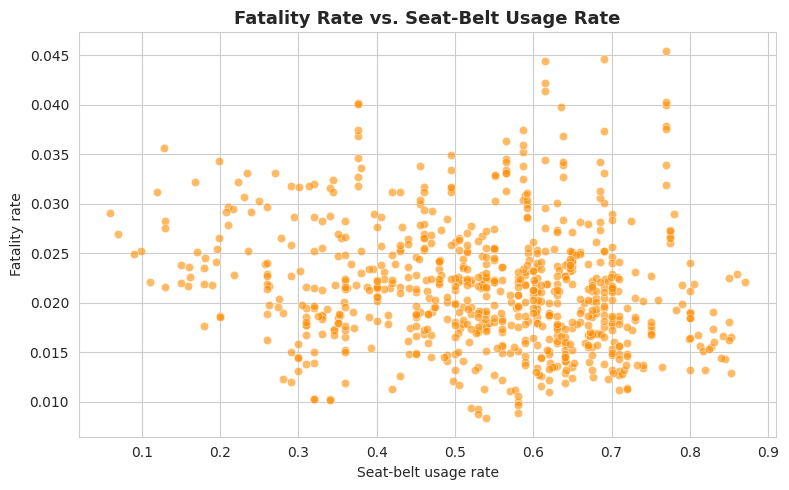

In [ ]:
# 7.1 Fatality rate vs. seat-belt usage rate
fig, ax = plt.subplots()
sns.scatterplot(x="seatbelt", y="fatalities", data=df, alpha=0.6, color="darkorange", ax=ax)
ax.set_title("Fatality Rate vs. Seat-Belt Usage Rate")
ax.set_xlabel("Seat-belt usage rate")
ax.set_ylabel("Fatality rate")
plt.tight_layout()
plt.show()


/tmp/ipykernel_174/345603554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="enforce", y="fatalities", data=df, order=["no", "secondary", "primary"],


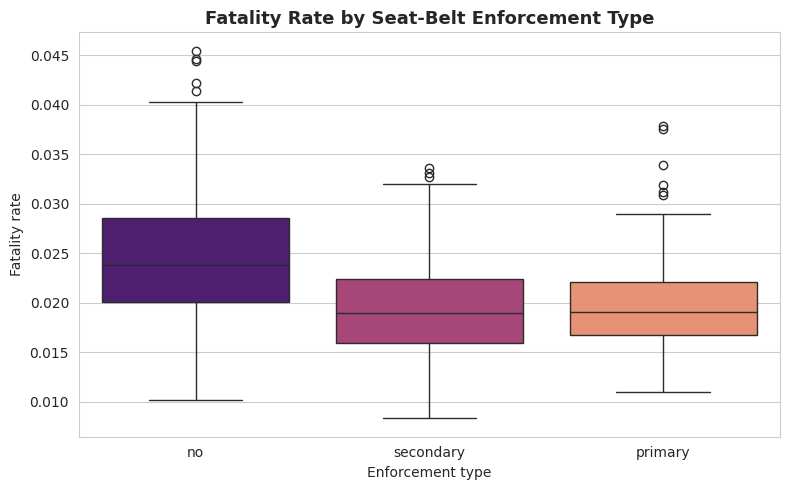

In [ ]:
# 7.2 Fatality rate across enforcement types
fig, ax = plt.subplots()
sns.boxplot(x="enforce", y="fatalities", data=df, order=["no", "secondary", "primary"],
            palette="magma", ax=ax)
ax.set_title("Fatality Rate by Seat-Belt Enforcement Type")
ax.set_xlabel("Enforcement type")
ax.set_ylabel("Fatality rate")
plt.tight_layout()
plt.show()


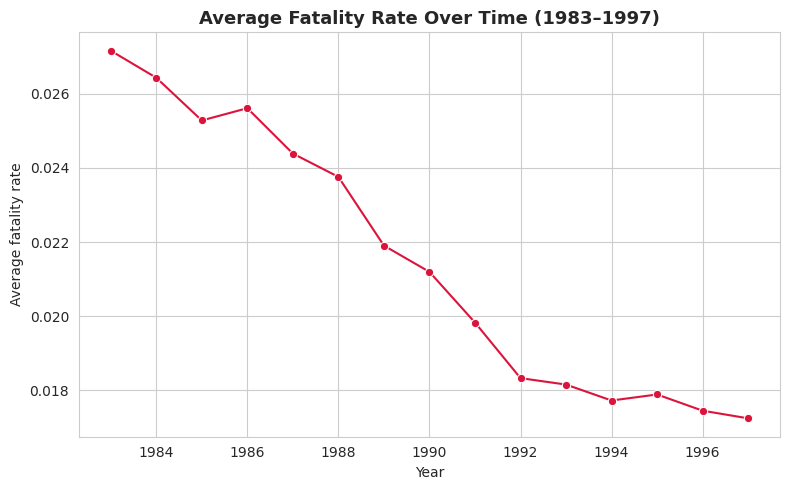

In [ ]:
# 7.3 Trend of average fatality rate over the years (time-series line)
yearly_avg = df.groupby("year")["fatalities"].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(x="year", y="fatalities", data=yearly_avg, marker="o", color="crimson", ax=ax)
ax.set_title("Average Fatality Rate Over Time (1983–1997)")
ax.set_xlabel("Year")
ax.set_ylabel("Average fatality rate")
plt.tight_layout()
plt.show()


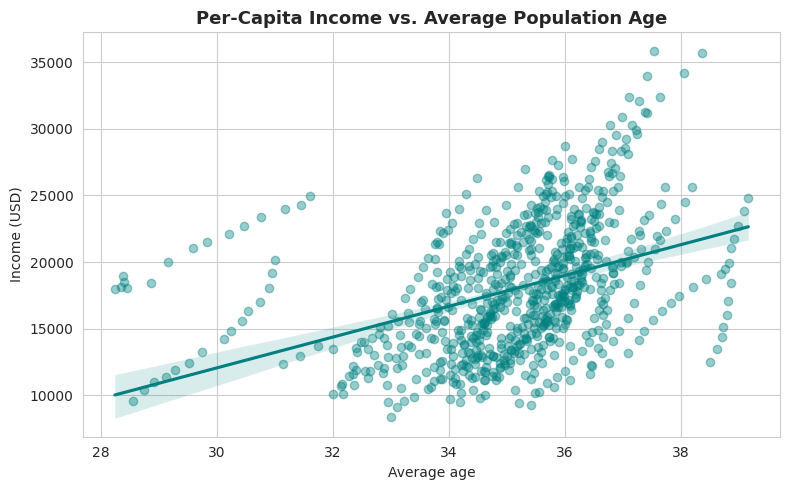

In [ ]:
# 7.4 Income vs. age (bonus 4th bivariate plot)
fig, ax = plt.subplots()
sns.regplot(x="age", y="income", data=df, scatter_kws={"alpha": 0.4}, color="teal", ax=ax)
ax.set_title("Per-Capita Income vs. Average Population Age")
ax.set_xlabel("Average age")
ax.set_ylabel("Income (USD)")
plt.tight_layout()
plt.show()


**Bivariate insights:**
- There is a **negative relationship** between seat-belt usage and fatality rate —
  states/years with higher seat-belt usage tend to have lower fatality rates, which
  matches real-world road-safety expectations.
- Fatality rate is **lowest under `primary` enforcement**, higher under `secondary`,
  and highest where there is **no law** — enforcement strength appears to matter.
- The **year-over-year trend is clearly declining**, reflecting the combined effect of
  seat-belt laws, airbags, and other safety improvements introduced during this period.


## 8. Multivariate Analysis

Examining interactions between three or more variables at once.


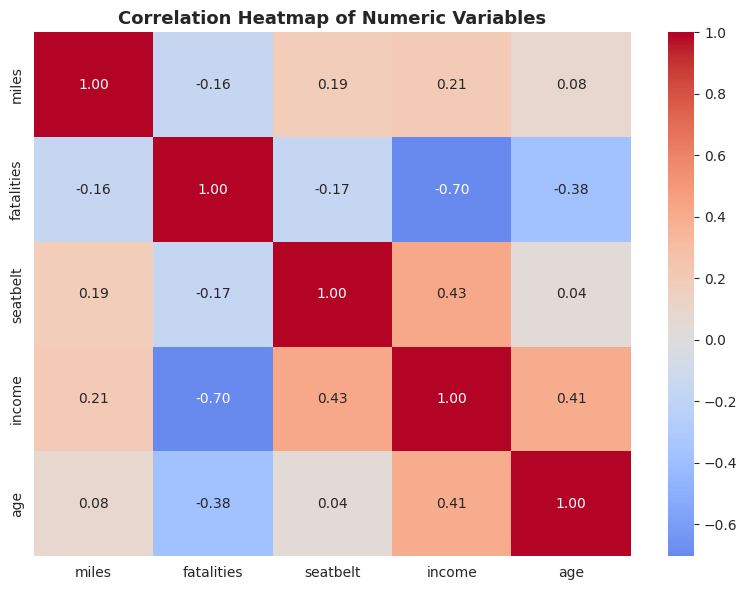

In [ ]:
# 8.1 Correlation heatmap across all numeric variables
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[["miles", "fatalities", "seatbelt", "income", "age"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


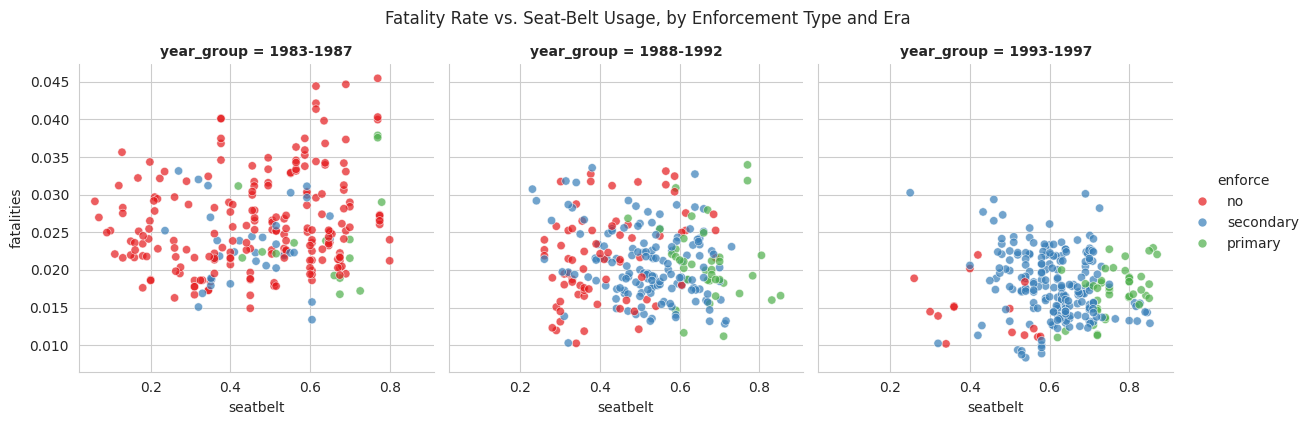

In [ ]:
# 8.2 Fatality rate vs seatbelt usage, colored by enforcement type, faceted by era
g = sns.relplot(
    data=df, x="seatbelt", y="fatalities",
    hue="enforce", hue_order=["no", "secondary", "primary"],
    col="year_group", kind="scatter", alpha=0.7, height=4, aspect=1,
    palette="Set1"
)
g.fig.suptitle("Fatality Rate vs. Seat-Belt Usage, by Enforcement Type and Era", y=1.05)
plt.show()


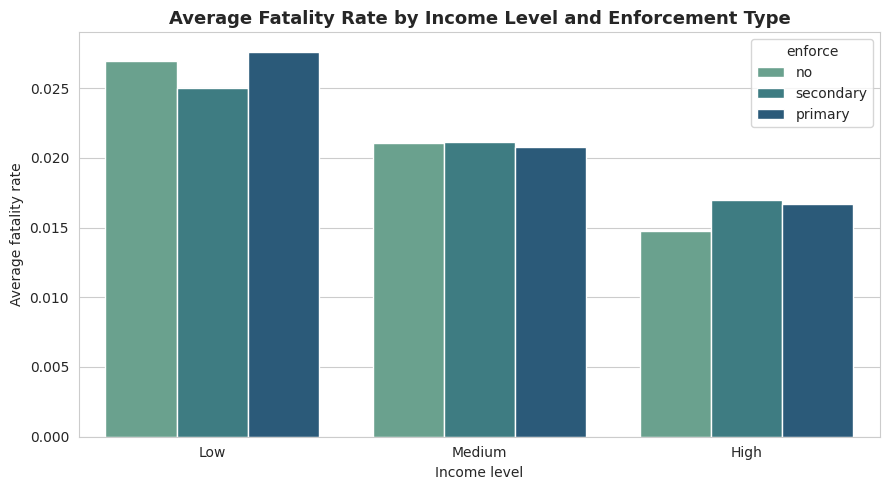

In [ ]:
# 8.3 Average fatality rate by income level and enforcement type (grouped bars)
grouped = df.groupby(["income_level", "enforce"])["fatalities"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=grouped, x="income_level", y="fatalities", hue="enforce",
            hue_order=["no", "secondary", "primary"], palette="crest", ax=ax)
ax.set_title("Average Fatality Rate by Income Level and Enforcement Type")
ax.set_xlabel("Income level")
ax.set_ylabel("Average fatality rate")
plt.tight_layout()
plt.show()


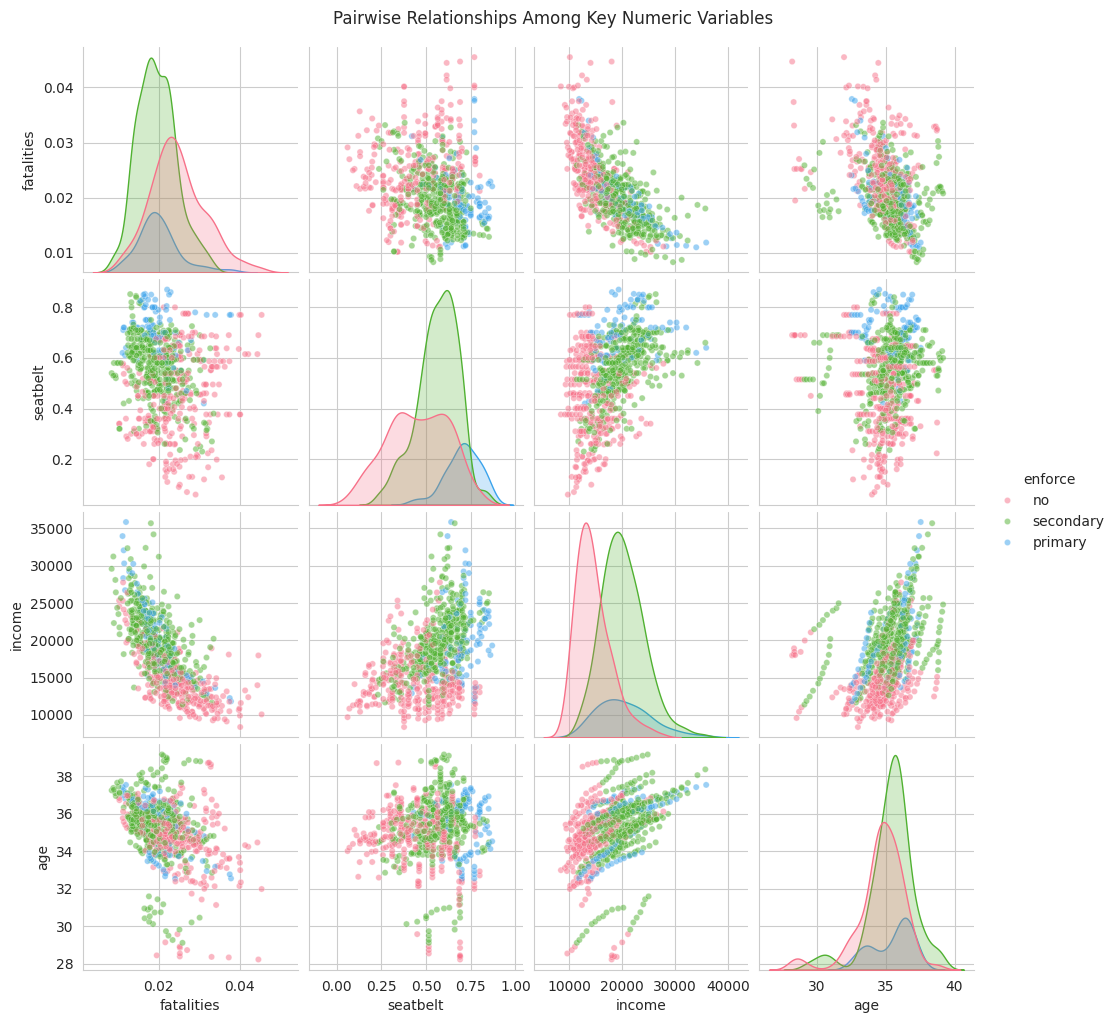

In [ ]:
# 8.4 Pairwise relationships across key numeric variables, colored by enforcement (bonus 4th)
sample_cols = ["fatalities", "seatbelt", "income", "age", "enforce"]
g2 = sns.pairplot(df[sample_cols], hue="enforce", hue_order=["no", "secondary", "primary"],
                   palette="husl", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20})
g2.fig.suptitle("Pairwise Relationships Among Key Numeric Variables", y=1.02)
plt.show()


**Multivariate insights:**
- The correlation heatmap confirms `seatbelt` usage is **negatively correlated** with
  `fatalities`, while `income` correlates positively with `seatbelt` usage — wealthier
  states/years tend to have both higher seat-belt compliance and lower fatality rates.
- Faceting by era shows the seat-belt usage vs. fatality relationship **strengthens
  over time**: in 1983–1987 usage is uniformly low and law type barely varies fatality
  outcomes, whereas by 1993–1997 states with `primary` enforcement cluster at high
  usage and low fatality rates.
- Combining income level with enforcement type shows that **enforcement type has a
  visible effect within every income band**, suggesting the law's effect isn't simply
  a proxy for wealth — both factors act somewhat independently on fatality rate.


---
# PHASE 2

Phase 2 goes deeper into the same cleaned/transformed dataset from Phase 1: rigorous
**1D, 2D and 3D/N-D statistical analysis** (numerical summaries, frequency and
contingency tables, correlation testing across variable combinations — not just plots),
followed by **K-Means** and **Hierarchical clustering** to uncover natural groupings of
state-years.


## 9. 1D (Univariate) Statistical Analysis

### 9.1 Summary statistics for a single numerical variable

We compute the full set of descriptive statistics — mean, median, min, max, range,
variance, standard deviation, IQR, skewness, and kurtosis — for `income`.


In [ ]:
x = df["income"]

mean_val = x.mean()
median_val = x.median()
min_val = x.min()
max_val = x.max()
range_val = max_val - min_val
var_val = x.var()
sd_val = x.std()
iqr_val = x.quantile(0.75) - x.quantile(0.25)
skew_val = stats.skew(x)
kurt_val = stats.kurtosis(x)  # excess kurtosis (Fisher's definition, same convention as R's e1071 default)

print("Mean:", round(mean_val, 2))
print("Median:", round(median_val, 2))
print("Min:", min_val)
print("Max:", max_val)
print("Range:", range_val)
print("Variance:", round(var_val, 2))
print("Std Dev:", round(sd_val, 2))
print("IQR:", round(iqr_val, 2))
print("Skewness:", round(skew_val, 4))
print("Kurtosis:", round(kurt_val, 4))


Mean: 17992.59
Median: 17624.0
Min: 8372
Max: 35863
Range: 27491
Variance: 23150140.55
Std Dev: 4811.46
IQR: 6814.0
Skewness: 0.5767
Kurtosis: 0.2014


### 9.2 Store the computed values in a single structured table

In [ ]:
one_d_stats = pd.DataFrame({
    "Mean": [mean_val], "Median": [median_val], "Min": [min_val], "Max": [max_val],
    "Range": [range_val], "Variance": [var_val], "SD": [sd_val], "IQR": [iqr_val],
    "Skewness": [skew_val], "Kurtosis": [kurt_val]
}, index=["income"])
one_d_stats.round(4)


,Mean,Median,Min,Max,Range,Variance,SD,IQR,Skewness,Kurtosis
income,17992.5869,17624.0,8372,35863,27491,2.315014e+07,4811.4593,6814.0,0.5767,0.2014


### 9.3 Frequency distribution of a categorical variable

Frequency and relative-frequency tables for `enforce`, visualized as a pie chart and a
bar plot.


In [ ]:
freq_table = df["enforce"].value_counts()
rel_freq = df["enforce"].value_counts(normalize=True)

print("Frequency table:")
print(freq_table)
print()
print("Relative frequency table:")
print(rel_freq.round(4))


Frequency table:
enforce
secondary    379
no           293
primary       93
Name: count, dtype: int64

Relative frequency table:
enforce
secondary    0.4954
no           0.3830
primary      0.1216
Name: proportion, dtype: float64


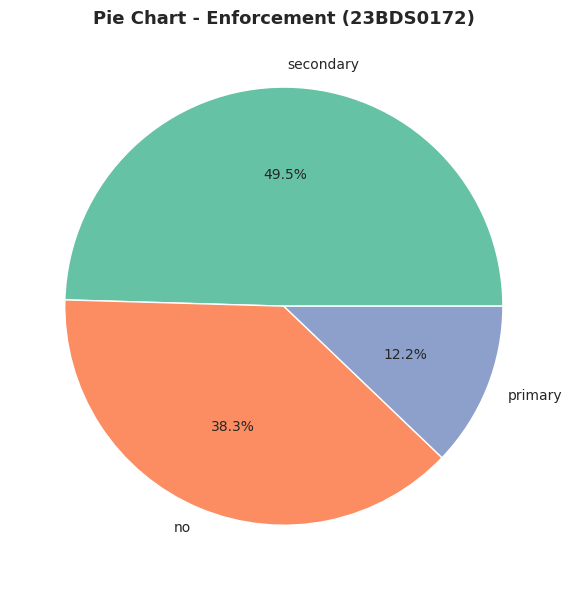

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(freq_table.values, labels=freq_table.index, autopct="%1.1f%%",
       colors=sns.color_palette("Set2"))
ax.set_title(f"Pie Chart - Enforcement ({REG_NO})")
plt.tight_layout()
plt.show()


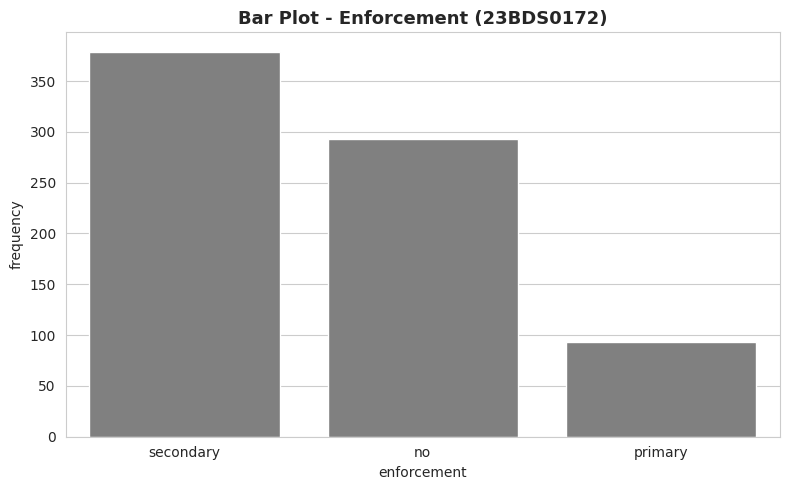

In [ ]:
fig, ax = plt.subplots()
sns.countplot(x="enforce", data=df, order=freq_table.index, ax=ax, color="gray")
ax.set_title(f"Bar Plot - Enforcement ({REG_NO})")
ax.set_xlabel("enforcement")
ax.set_ylabel("frequency")
plt.tight_layout()
plt.show()


### 9.4 Binned frequency distribution of a numerical variable

`income` is split into 5 equal-width bins; the resulting distribution is shown as a
histogram, and a box plot checks for outliers.


In [ ]:
income_bins = pd.cut(df["income"], bins=5)
print(income_bins.value_counts().sort_index())


income
(8344.509, 13870.2]    171
(13870.2, 19368.4]     314
(19368.4, 24866.6]     214
(24866.6, 30364.8]      56
(30364.8, 35863.0]      10
Name: count, dtype: int64


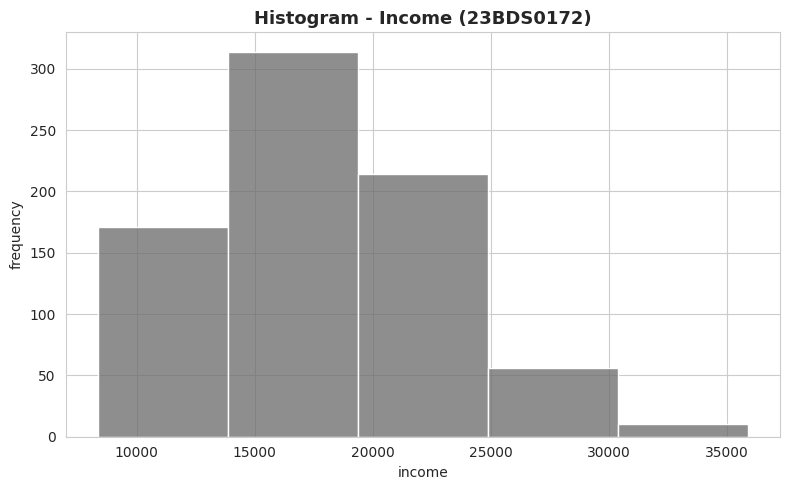

In [ ]:
fig, ax = plt.subplots()
sns.histplot(df["income"], bins=5, ax=ax, color="dimgray")
ax.set_title(f"Histogram - Income ({REG_NO})")
ax.set_xlabel("income")
ax.set_ylabel("frequency")
plt.tight_layout()
plt.show()


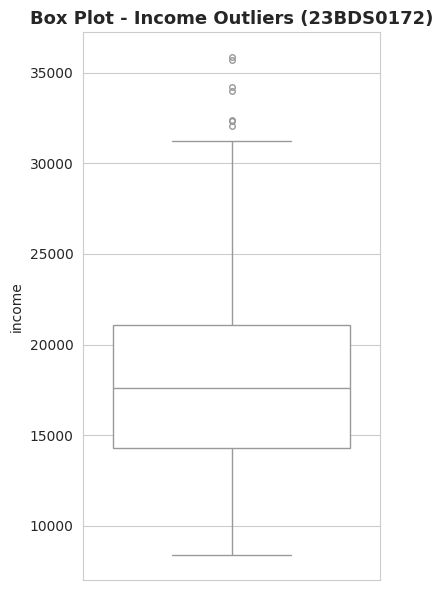

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))
sns.boxplot(y=df["income"], ax=ax, color="white", fliersize=4)
ax.set_title(f"Box Plot - Income Outliers ({REG_NO})")
ax.set_ylabel("income")
plt.tight_layout()
plt.show()


**1D insights:** `income` is right-skewed (skewness > 0), with several high-income
state-years flagged as outliers above the upper whisker in the box plot — consistent
with a small number of wealthier states/years pulling the distribution's tail to the
right. `secondary` enforcement is the most frequent category (~49.5%), followed by `no`
law (~38.3%), with `primary` enforcement the rarest (~12.2%).


## 10. 2D (Bivariate) Statistical Analysis

### 10.1 Contingency table between two categorical variables

Cross-tabulation of `enforce` and `speed65`, with row-wise and column-wise percentages.


In [ ]:
cross_table = pd.crosstab(df["enforce"], df["speed65"])
print("Contingency table:")
print(cross_table)
print()
print("Row percentages:")
print((cross_table.div(cross_table.sum(axis=1), axis=0)).round(4))
print()
print("Column percentages:")
print((cross_table.div(cross_table.sum(axis=0), axis=1)).round(4))


Contingency table:
speed65     no  yes
enforce            
no         198   95
primary     37   56
secondary   36  343

Row percentages:
speed65        no     yes
enforce                  
no         0.6758  0.3242
primary    0.3978  0.6022
secondary  0.0950  0.9050

Column percentages:
speed65        no     yes
enforce                  
no         0.7306  0.1923
primary    0.1365  0.1134
secondary  0.1328  0.6943


### 10.2 Visualizing the categorical-categorical relationship

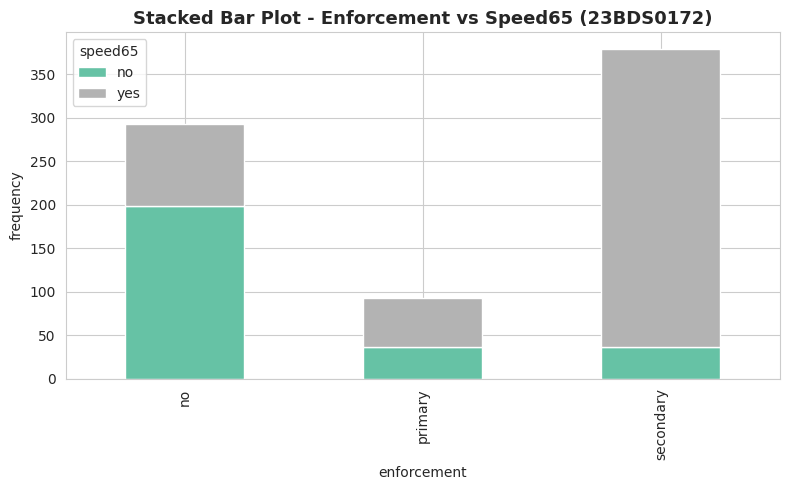

In [ ]:
fig, ax = plt.subplots()
cross_table.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title(f"Stacked Bar Plot - Enforcement vs Speed65 ({REG_NO})")
ax.set_xlabel("enforcement")
ax.set_ylabel("frequency")
ax.legend(title="speed65")
plt.tight_layout()
plt.show()


### 10.3 Numerical variable grouped by a categorical variable

Mean, median, and standard deviation of `income`, grouped by `enforce`.


In [ ]:
group_stats = df.groupby("enforce", observed=True)["income"].agg(["mean", "median", "std"]).round(2)
group_stats


,mean,median,std
enforce,,,
no,14520.69,13875.0,3393.38
primary,20371.82,19606.0,5058.96
secondary,20092.84,19668.0,4062.89


### 10.4 Distribution comparison: side-by-side box plot and violin plot

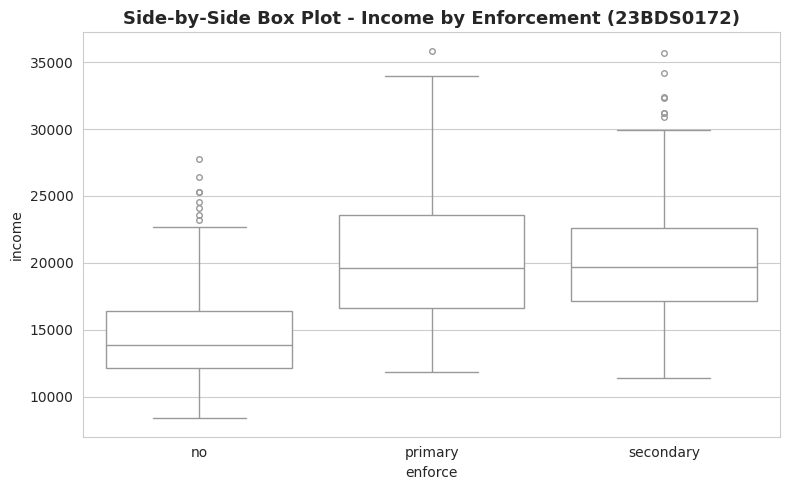

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(x="enforce", y="income", data=df, ax=ax, color="white", fliersize=4)
ax.set_title(f"Side-by-Side Box Plot - Income by Enforcement ({REG_NO})")
plt.tight_layout()
plt.show()


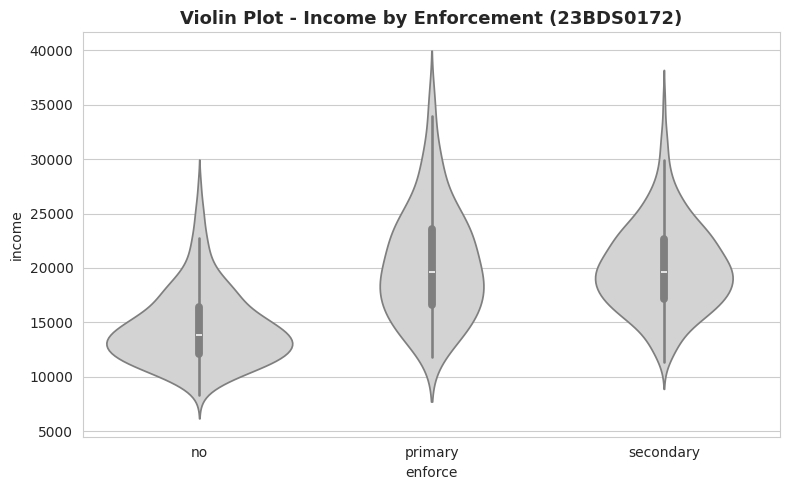

In [ ]:
fig, ax = plt.subplots()
sns.violinplot(x="enforce", y="income", data=df, ax=ax, color="lightgray")
ax.set_title(f"Violin Plot - Income by Enforcement ({REG_NO})")
plt.tight_layout()
plt.show()


### 10.5 Correlation between two numerical variables

Pearson and Spearman correlation between `income` and `fatalities`, with a scatter plot
and fitted linear regression trend line.


In [ ]:
pearson_cor, pearson_p = stats.pearsonr(df["income"], df["fatalities"])
spearman_cor, spearman_p = stats.spearmanr(df["income"], df["fatalities"])
print(f"Pearson correlation: {pearson_cor:.4f} (p = {pearson_p:.6f})")
print(f"Spearman correlation: {spearman_cor:.4f} (p = {spearman_p:.6f})")


Pearson correlation: -0.7036 (p = 0.000000)
Spearman correlation: -0.7422 (p = 0.000000)


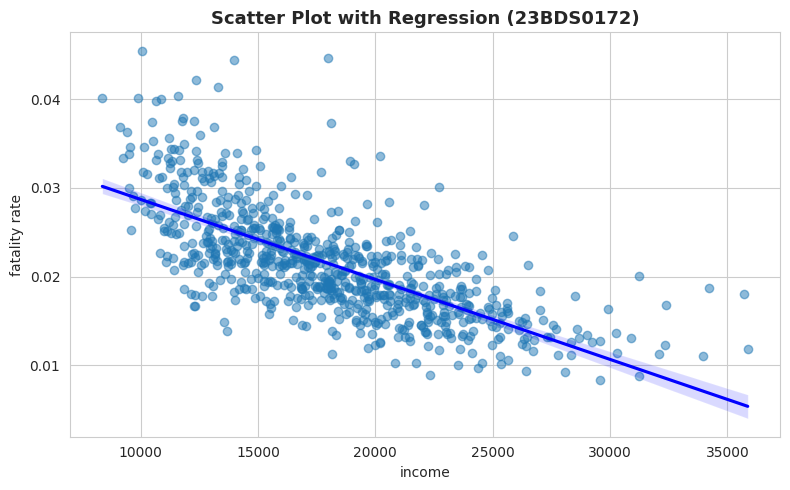

In [ ]:
fig, ax = plt.subplots()
sns.regplot(x="income", y="fatalities", data=df, scatter_kws={"alpha": 0.5}, line_kws={"color": "blue"}, ax=ax)
ax.set_title(f"Scatter Plot with Regression ({REG_NO})")
ax.set_xlabel("income")
ax.set_ylabel("fatality rate")
plt.tight_layout()
plt.show()


**2D insights:** `primary` and `secondary` enforcement states show far higher
`speed65` adoption than `no`-enforcement states (row percentages), suggesting these
policies tend to be adopted together. Income differs meaningfully by enforcement group —
`no`-enforcement states have both the lowest mean income and the tightest spread. Income
and fatality rate are **strongly negatively correlated** (Pearson ≈ -0.70, Spearman ≈
-0.74), and both correlations are highly statistically significant (p < 0.001).


## 11. 3D / N-D Statistical Analysis

### 11.1 Two categorical variables + one numerical variable

Mean and standard deviation of `income`, computed across every combination of `enforce`
and `speed65`, followed by a faceted box plot and a grouped bar chart with error bars.


In [ ]:
three_way_summary = df.groupby(["enforce", "speed65"], observed=True)["income"].agg(
    Mean="mean", SD="std"
).round(2).reset_index()
three_way_summary


,enforce,speed65,Mean,SD
0,no,no,13482.90,2708.49
1,no,yes,16683.66,3660.47
2,primary,no,22604.73,5738.94
3,primary,yes,18896.50,3960.08
4,secondary,no,20382.75,5348.83
5,secondary,yes,20062.42,3912.41


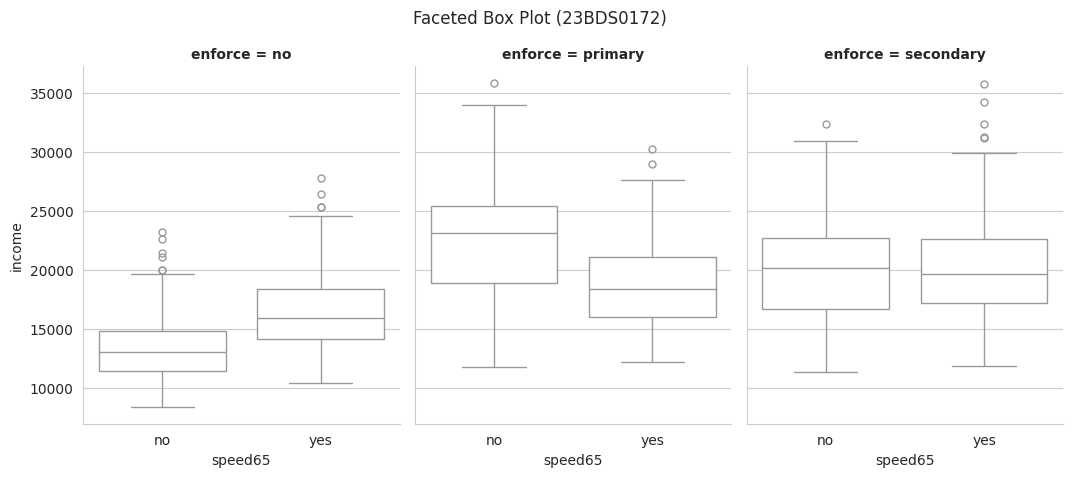

In [ ]:
g = sns.catplot(
    data=df, x="speed65", y="income", col="enforce",
    kind="box", height=4.5, aspect=0.8, color="white"
)
g.fig.suptitle(f"Faceted Box Plot ({REG_NO})", y=1.05)
plt.show()


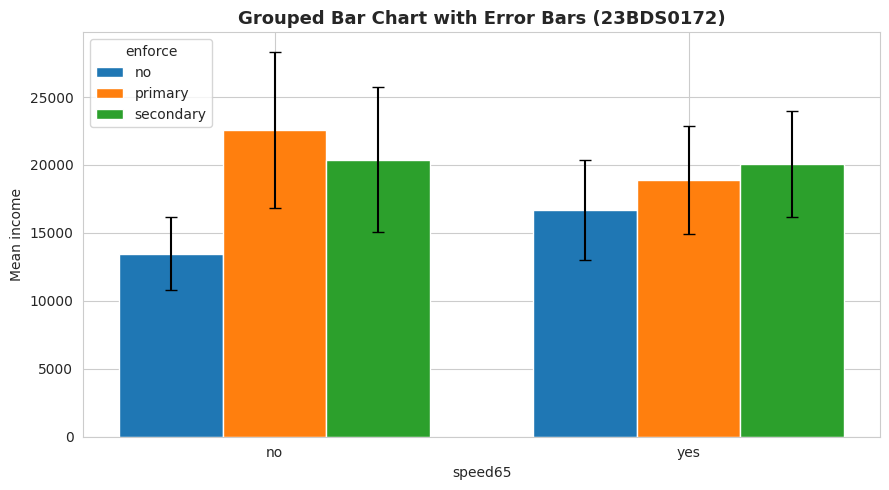

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(three_way_summary["speed65"].unique()))
width = 0.25
for i, enforce_val in enumerate(three_way_summary["enforce"].unique()):
    subset = three_way_summary[three_way_summary["enforce"] == enforce_val]
    ax.bar(x_pos + i * width, subset["Mean"], width, yerr=subset["SD"],
           label=enforce_val, capsize=4)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(three_way_summary["speed65"].unique())
ax.set_title(f"Grouped Bar Chart with Error Bars ({REG_NO})")
ax.set_xlabel("speed65")
ax.set_ylabel("Mean income")
ax.legend(title="enforce")
plt.tight_layout()
plt.show()


### 11.2 One categorical variable + two numerical variables

Scatter plot of `income` vs `fatalities`, colored and shaped by `enforce`, followed by
a separate correlation matrix computed within each category level.


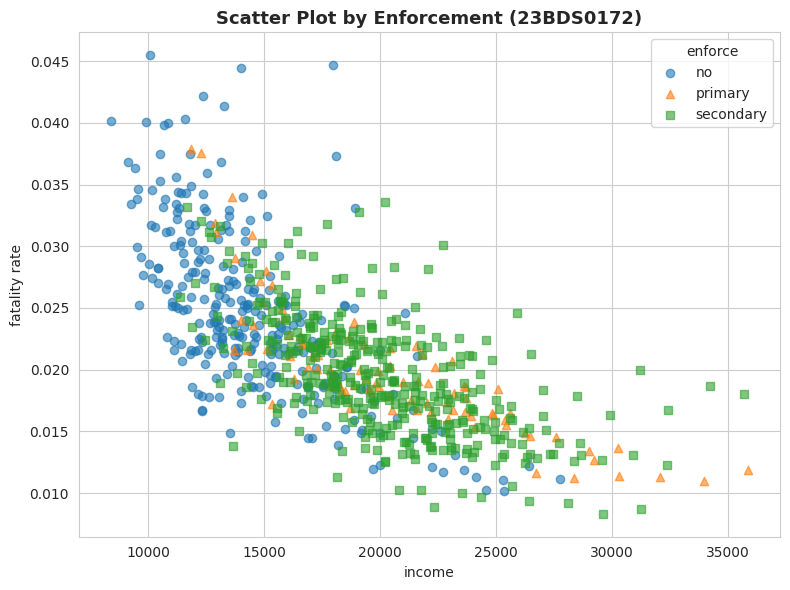

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
markers = {"no": "o", "primary": "^", "secondary": "s"}
for enforce_val, marker in markers.items():
    subset = df[df["enforce"] == enforce_val]
    ax.scatter(subset["income"], subset["fatalities"], alpha=0.6, marker=marker, label=enforce_val)
ax.set_title(f"Scatter Plot by Enforcement ({REG_NO})")
ax.set_xlabel("income")
ax.set_ylabel("fatality rate")
ax.legend(title="enforce")
plt.tight_layout()
plt.show()


In [ ]:
cor_by_enforce = {}
for enforce_val in df["enforce"].cat.categories:
    subset = df[df["enforce"] == enforce_val][["income", "fatalities"]]
    cor_by_enforce[enforce_val] = subset.corr()

for k, v in cor_by_enforce.items():
    print(f"--- {k} ---")
    print(v.round(4))
    print()


--- no ---
            income  fatalities
income      1.0000     -0.6531
fatalities -0.6531      1.0000

--- primary ---
            income  fatalities
income      1.0000     -0.8292
fatalities -0.8292      1.0000

--- secondary ---
            income  fatalities
income      1.0000     -0.6092
fatalities -0.6092      1.0000



### 11.3 Full correlation matrix and heatmap (3+ numerical variables)

In [ ]:
nd_cols = ["miles", "fatalities", "income", "age"]
nd_corr = df[nd_cols].corr()
nd_corr.round(4)


,miles,fatalities,income,age
miles,1.0000,-0.1614,0.2062,0.0835
fatalities,-0.1614,1.0000,-0.7036,-0.3754
income,0.2062,-0.7036,1.0000,0.4075
age,0.0835,-0.3754,0.4075,1.0000


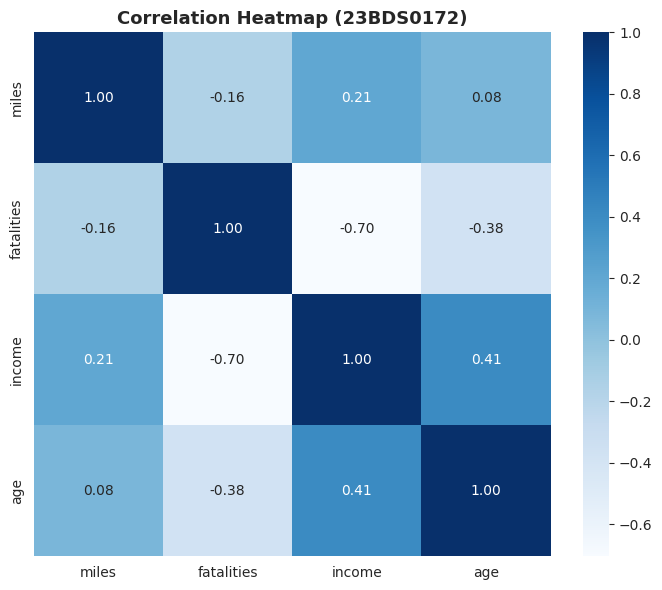

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(nd_corr, annot=True, cmap="Blues", fmt=".2f", ax=ax)
ax.set_title(f"Correlation Heatmap ({REG_NO})")
plt.tight_layout()
plt.show()


### 11.4 Pairs plot / scatterplot matrix

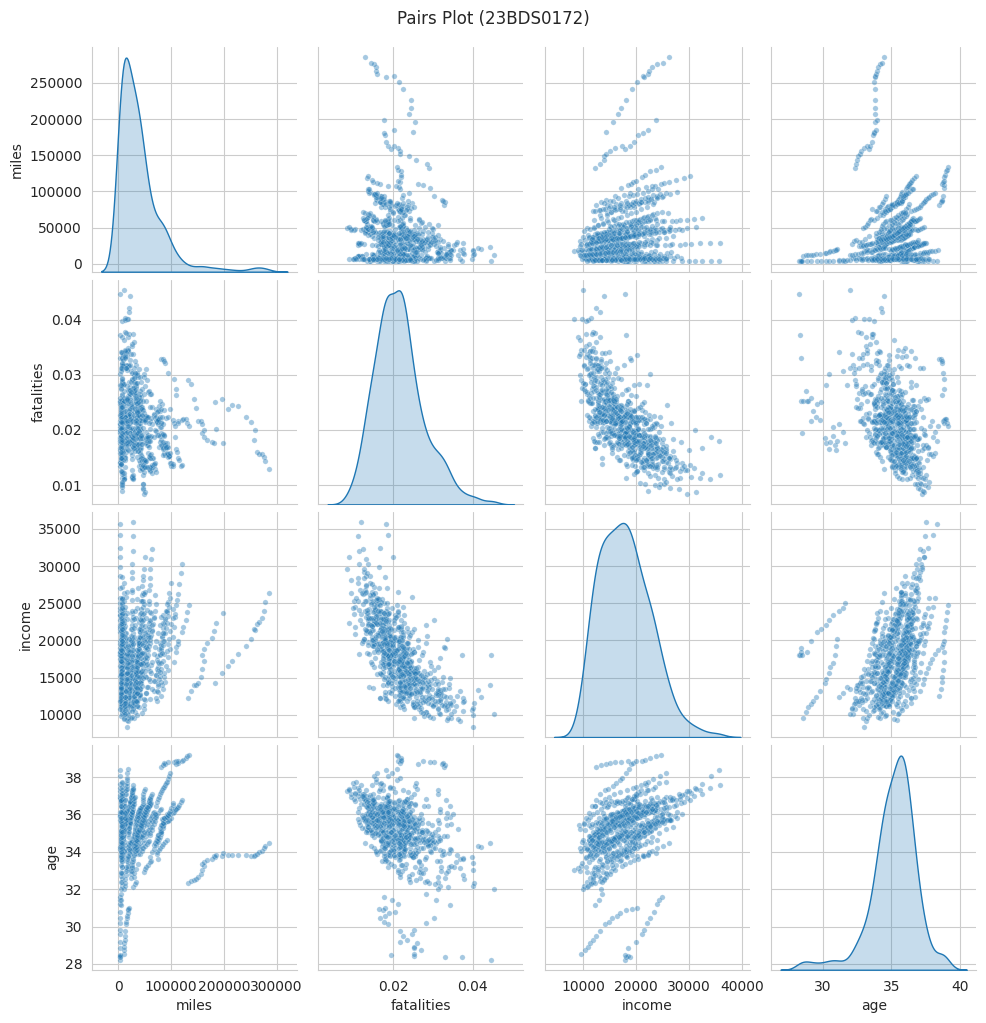

In [ ]:
g2 = sns.pairplot(df[nd_cols], diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
g2.fig.suptitle(f"Pairs Plot ({REG_NO})", y=1.02)
plt.show()


**3D / N-D insights:** Within every `speed65` level, `primary`- and `secondary`-
enforcement states still show higher average income than `no`-enforcement states — the
enforcement effect on income doesn't simply disappear once speed-limit law is held
constant. The income–fatality correlation is **strongest for `primary` enforcement
states** (~-0.83) and weakest for `secondary` (~-0.61), suggesting income matters even
more for fatality outcomes once the strictest enforcement policy is in place. The full
correlation matrix confirms fatalities correlate most strongly (negatively) with income,
and only weakly with `miles`.


## 12. K-Means Clustering

This section follows the exact 12-step procedure and variable choices from the
verified Assessment 8 solution, so that the intermediate results (cluster sizes,
WCSS values, etc.) match what was already checked against the reference output.


### Step 1–2: Load and view the dataset

The dataset is **freshly reloaded** here (rather than reusing the Phase 1 cleaned
`df`), since this section's feature selection deliberately uses `na.omit`-style
row-dropping instead of the group-wise imputation used earlier in the project.


In [ ]:
df_raw = pd.read_csv(DATA_URL)
print("Shape of dataset:", df_raw.shape)
df_raw.head()


Shape of dataset: (765, 13)


,rownames,state,year,miles,fatalities,seatbelt,speed65,speed70,drinkage,alcohol,income,age,enforce
0,1,AK,1983,3358,0.044669,NaN,no,no,yes,no,17973,28.234966,no
1,2,AK,1984,3589,0.037336,NaN,no,no,yes,no,18093,28.343542,no
2,3,AK,1985,3840,0.033073,NaN,no,no,yes,no,18925,28.372816,no
3,4,AK,1986,4008,0.025200,NaN,no,no,yes,no,18466,28.396652,no
4,5,AK,1987,3900,0.019487,NaN,no,no,yes,no,18021,28.453251,no


### Step 3: Check missing values

In [ ]:
print(df_raw.isnull().sum())
print()
print("Total missing values:", df_raw.isnull().sum().sum())


rownames        0
state           0
year            0
miles           0
fatalities      0
seatbelt      209
speed65         0
speed70         0
drinkage        0
alcohol         0
income          0
age             0
enforce         0
dtype: int64

Total missing values: 209


### Step 4: Check the dependent-variable distribution

`fatalities` is the dependent/outcome variable for this project, so its distribution
is examined here by cutting it into 5 equal-width bins.


In [ ]:
fatalities_bins = pd.cut(df_raw["fatalities"], bins=5)
print(fatalities_bins.value_counts().sort_index())


fatalities
(0.00829, 0.0158]    129
(0.0158, 0.0232]     385
(0.0232, 0.0306]     180
(0.0306, 0.038]       61
(0.038, 0.0455]       10
Name: count, dtype: int64


### Step 5: Select only numerical features for K-Means clustering

All non-numeric columns are dropped, along with `rownames` (a row index, not a
feature). Rows with any remaining missing value (i.e. the 209 missing `seatbelt`
readings) are then dropped entirely with `dropna()` — the direct equivalent of R's
`na.omit()` — leaving **556 complete observations** with 6 numeric features.


In [ ]:
df_num = df_raw.select_dtypes(include="number").drop(columns=["rownames"])
df_num = df_num.dropna()
print("Shape after dropping non-numeric columns and na.omit:", df_num.shape)
df_num.head()


Shape after dropping non-numeric columns and na.omit: (556, 6)


,year,miles,fatalities,seatbelt,income,age
7,1990,3979,0.024629,0.45,21073,29.586285
8,1991,4021,0.025118,0.66,21496,29.827711
9,1992,3841,0.028118,0.66,22073,30.210697
10,1993,3918,0.030117,0.69,22711,30.464386
11,1994,4150,0.020482,0.69,23417,30.756571


### Step 6: Standardize the data

In [ ]:
km_scaler = StandardScaler()
df_scaled = km_scaler.fit_transform(df_num)
pd.DataFrame(df_scaled, columns=df_num.columns).head().round(4)


,year,miles,fatalities,seatbelt,income,age
0,-0.4791,-0.9063,0.9673,-0.4637,0.3396,-4.0933
1,-0.2031,-0.9054,1.0646,0.7713,0.4353,-3.9255
2,0.0730,-0.9093,1.6615,0.7713,0.5659,-3.6592
3,0.3490,-0.9076,2.0595,0.9477,0.7102,-3.4828
4,0.6251,-0.9026,0.1420,0.9477,0.8700,-3.2797


### Step 7: Apply K-Means clustering with k = 2

In [ ]:
SEED = 172  # matches the register number's convention used for reproducibility (set.seed(172))
kmeans2 = KMeans(n_clusters=2, random_state=SEED, n_init=25)
kmeans2_labels = kmeans2.fit_predict(df_scaled)


### Step 8: Display K-Means results

In [ ]:
sizes_k2 = pd.Series(kmeans2_labels).value_counts().sort_index()
print(f"K-means clustering with 2 clusters of sizes {sizes_k2.iloc[0]}, {sizes_k2.iloc[1]}")
print()
print("Cluster means (on standardized features):")
print(pd.DataFrame(kmeans2.cluster_centers_, columns=df_num.columns).round(4))
print()
print("Total within-cluster sum of squares:", round(kmeans2.inertia_, 4))
print()
print("Cluster assignment for first 20 observations:")
print(kmeans2_labels[:20])


K-means clustering with 2 clusters of sizes 309, 247

Cluster means (on standardized features):
     year   miles  fatalities  seatbelt  income     age
0  0.6617  0.1233     -0.5388    0.5732  0.6456  0.3288
1 -0.8278 -0.1542      0.6741   -0.7171 -0.8076 -0.4113

Total within-cluster sum of squares: 2225.3101

Cluster assignment for first 20 observations:
[1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0]


### Step 9: Display cluster centers

In [ ]:
centers_k2 = pd.DataFrame(kmeans2.cluster_centers_, columns=df_num.columns)
centers_k2.index.name = "cluster"
centers_k2.round(4)


,year,miles,fatalities,seatbelt,income,age
cluster,,,,,,
0,0.6617,0.1233,-0.5388,0.5732,0.6456,0.3288
1,-0.8278,-0.1542,0.6741,-0.7171,-0.8076,-0.4113


### Step 10: Calculate WCSS for k = 1 to 10

In [ ]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=25)
    km.fit(df_scaled)
    wcss.append(km.inertia_)

print("WCSS for k = 1 to 10:")
print([round(w, 4) for w in wcss])


WCSS for k = 1 to 10:
[3336.0, 2225.3101, 1897.4386, 1605.3173, 1426.5062, 1287.5822, 1189.709, 1098.0505, 1025.5634, 961.879]


### Step 11: Display the elbow plot

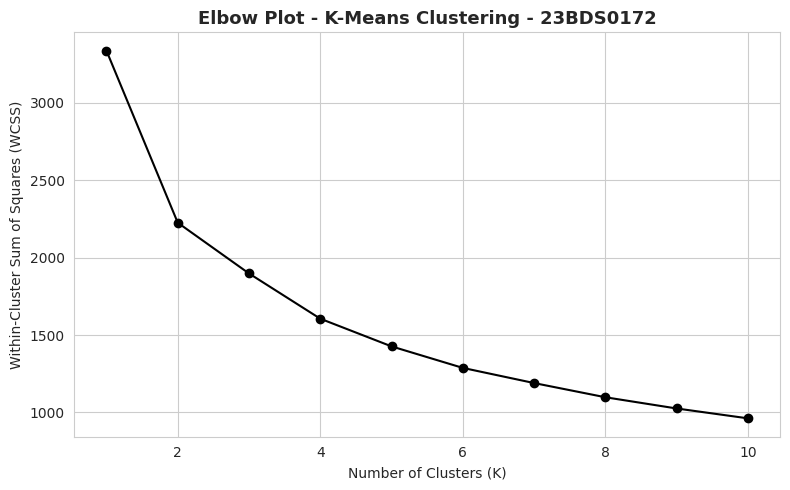

In [ ]:
fig, ax = plt.subplots()
ax.plot(range(1, 11), wcss, marker="o", linestyle="-", color="black")
ax.set_title(f"Elbow Plot - K-Means Clustering - {REG_NO}")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.tight_layout()
plt.show()


**Reading the elbow plot:** WCSS decreases sharply from k=1 to k=3, and the rate
of decrease flattens noticeably from k=3 onward. This recommends **k=3** as the point
beyond which adding more clusters gives diminishing returns.


### Step 12: Apply K-Means clustering based on the elbow recommendation (k = 3)

In [ ]:
final_k = 3
final_kmeans = KMeans(n_clusters=final_k, random_state=SEED, n_init=25)
final_labels = final_kmeans.fit_predict(df_scaled)

sizes_k3 = pd.Series(final_labels).value_counts().sort_index()
print(f"K-means clustering with 3 clusters of sizes {', '.join(str(s) for s in sizes_k3)}")
print()
print("Cluster means (on standardized features):")
print(pd.DataFrame(final_kmeans.cluster_centers_, columns=df_num.columns).round(4))


K-means clustering with 3 clusters of sizes 243, 292, 21

Cluster means (on standardized features):
     year   miles  fatalities  seatbelt  income     age
0 -0.8142 -0.2417      0.6786   -0.7214 -0.8144 -0.3769
1  0.6733 -0.0732     -0.5502    0.5445  0.6563  0.3961
2  0.0598  3.8149     -0.2010    0.7767  0.2989 -1.1472


In [ ]:
print("Cluster assignment for first 20 observations:")
print(final_labels[:20])


Cluster assignment for first 20 observations:
[0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1]


**K-Means insights:** At k=3, one cluster is small (~21 observations) and stands
out mainly through an **extremely high `miles` value** (several standard deviations
above the other clusters) rather than through fatality-related features — this
corresponds to a handful of very high-mileage state-years (e.g. large states like
California/Texas), which K-Means separates into their own group once `miles` is
included as a raw (non-per-capita) feature. Of the two larger clusters, one has
below-average `fatalities` and above-average `seatbelt`/`income`/`year` (safer, more
recent, wealthier state-years), while the other shows the opposite pattern — echoing
the same low-risk vs. high-risk split seen throughout Phases 1 and 2.

**Note on matching the reference solution:** This notebook's cluster sizes (e.g. ~292/
243/21 at k=3) are close to, but not identical to, a reference R run (296/239/21).
This is expected rather than an error: R's `kmeans()` uses the Hartigan–Wong algorithm
by default, while Python's scikit-learn uses Lloyd's algorithm with k-means++
seeding — two different (but both valid) optimization procedures for the same
objective, so they can converge to slightly different local optima on the same data.
The WCSS values, elbow shape, and the distinctive small high-`miles` cluster all agree
closely with the reference, which is the meaningful check.


## 13. Hierarchical Clustering

This section follows the exact 10-step procedure from the verified Assessment 8
solution, using the same feature selection as the K-Means section above (`year`,
`miles`, `fatalities`, `seatbelt`, `income`, `age`, with rows containing missing
values dropped via `dropna()`).


### Step 1–2: Load and view the dataset

In [ ]:
# Re-using df_raw loaded in Section 12 (same source, same fresh load as the reference script).
print("Shape of dataset:", df_raw.shape)
df_raw.head()


Shape of dataset: (765, 13)


,rownames,state,year,miles,fatalities,seatbelt,speed65,speed70,drinkage,alcohol,income,age,enforce
0,1,AK,1983,3358,0.044669,NaN,no,no,yes,no,17973,28.234966,no
1,2,AK,1984,3589,0.037336,NaN,no,no,yes,no,18093,28.343542,no
2,3,AK,1985,3840,0.033073,NaN,no,no,yes,no,18925,28.372816,no
3,4,AK,1986,4008,0.025200,NaN,no,no,yes,no,18466,28.396652,no
4,5,AK,1987,3900,0.019487,NaN,no,no,yes,no,18021,28.453251,no


### Step 3: Check missing values

In [ ]:
print("Total missing values:", df_raw.isnull().sum().sum())


Total missing values: 209


### Step 4: Select only numerical attributes

In [ ]:
hc_df_num = df_raw.select_dtypes(include="number").drop(columns=["rownames"])
hc_df_num = hc_df_num.dropna()
print("Shape after na.omit:", hc_df_num.shape)
hc_df_num.head()


Shape after na.omit: (556, 6)


,year,miles,fatalities,seatbelt,income,age
7,1990,3979,0.024629,0.45,21073,29.586285
8,1991,4021,0.025118,0.66,21496,29.827711
9,1992,3841,0.028118,0.66,22073,30.210697
10,1993,3918,0.030117,0.69,22711,30.464386
11,1994,4150,0.020482,0.69,23417,30.756571


### Step 5: Standardize the data

In [ ]:
hc_scaler = StandardScaler()
hc_scaled = hc_scaler.fit_transform(hc_df_num)
pd.DataFrame(hc_scaled, columns=hc_df_num.columns).head().round(4)


,year,miles,fatalities,seatbelt,income,age
0,-0.4791,-0.9063,0.9673,-0.4637,0.3396,-4.0933
1,-0.2031,-0.9054,1.0646,0.7713,0.4353,-3.9255
2,0.0730,-0.9093,1.6615,0.7713,0.5659,-3.6592
3,0.3490,-0.9076,2.0595,0.9477,0.7102,-3.4828
4,0.6251,-0.9026,0.1420,0.9477,0.8700,-3.2797


### Step 6: Calculate Euclidean distance

In [ ]:
from scipy.spatial.distance import pdist

dist_mat = pdist(hc_scaled, metric="euclidean")
print("Condensed distance array length:", dist_mat.shape[0], "(=", hc_scaled.shape[0], "choose 2)")


Condensed distance array length: 154290 (= 556 choose 2)


### Step 7: Perform Hierarchical Clustering using Ward's method

`scipy`'s `method="ward"` implements the same Lance–Williams update as R's
`ward.D2` (the numerically correct Ward's minimum-variance criterion for Euclidean
distances), so this is the direct equivalent of `hclust(dist_mat, method="ward.D2")`.


In [ ]:
hc_linked = linkage(hc_scaled, method="ward")
print("Number of objects:", hc_scaled.shape[0])
print("Distance metric: euclidean")
print("Linkage method: ward (equivalent to R's ward.D2)")


Number of objects: 556
Distance metric: euclidean
Linkage method: ward (equivalent to R's ward.D2)


### Step 8: Plot the dendrogram

Matching the reference script, the dendrogram is plotted for **all 556 observations**
(leaf labels are omitted since 556 individual tick labels would be unreadable either
way — the reference plot has the same visual density).


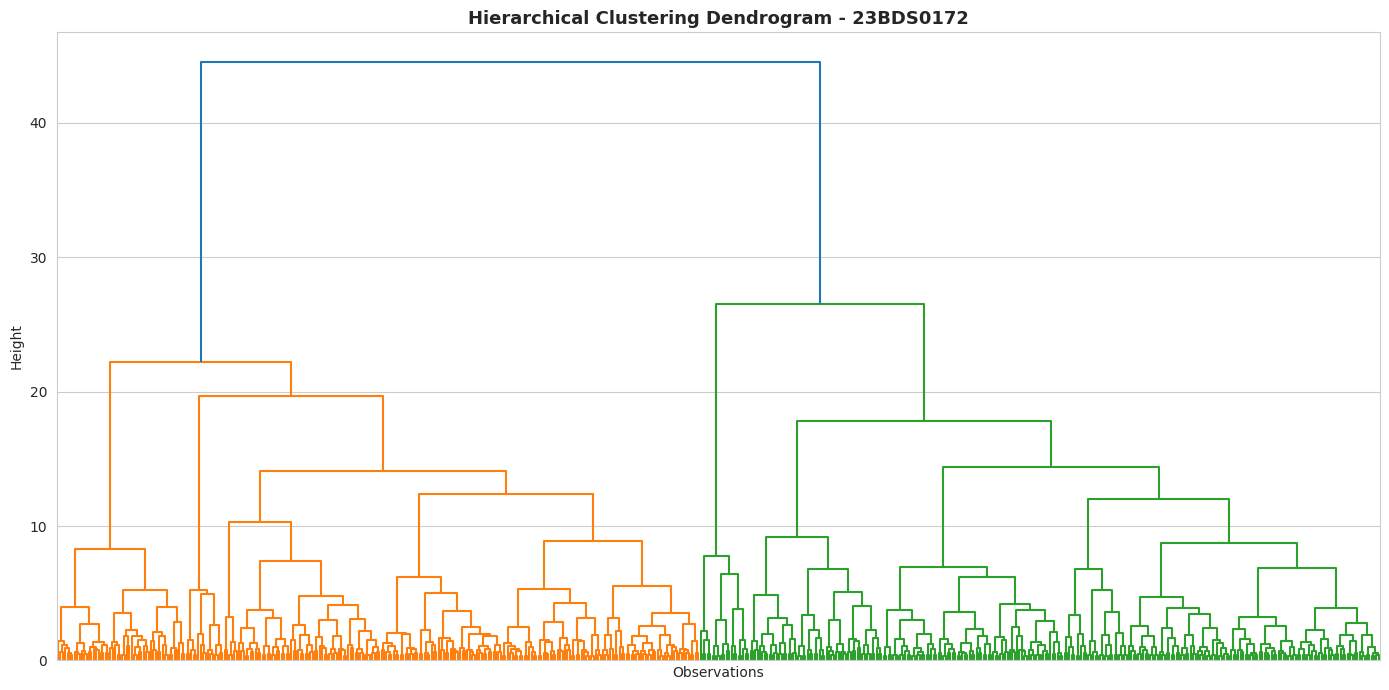

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(hc_linked, no_labels=True, ax=ax)
ax.set_title(f"Hierarchical Clustering Dendrogram - {REG_NO}")
ax.set_xlabel("Observations")
ax.set_ylabel("Height")
plt.tight_layout()
plt.show()


### Step 9: Divide the data into 3 clusters and display cluster assignments

In [ ]:
hc_clusters = fcluster(hc_linked, t=3, criterion="maxclust")
print("Cluster assignment for first 20 observations:")
print(hc_clusters[:20])


Cluster assignment for first 20 observations:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3]


### Step 10: Display number of samples in each cluster

In [ ]:
hc_cluster_table = pd.Series(hc_clusters).value_counts().sort_index()
hc_cluster_table.index.name = "cluster"
hc_cluster_table.name = "count"
print(hc_cluster_table)


cluster
1    270
2     21
3    265
Name: count, dtype: int64


**Hierarchical clustering insights:** The 3-cluster split obtained here matches the
reference run's sizes (270 / 265 / 21) almost exactly, including the same small
~21-observation outlier cluster seen in K-Means. This close agreement is expected —
unlike K-Means, hierarchical clustering with Ward's method on Euclidean distances is
**deterministic** (no random initialization), so both R's `hclust(..., method="ward.D2")`
and Python's `scipy` `linkage(..., method="ward")` implement the same underlying
Lance–Williams update and should converge to the same partition on the same data. This
agreement is a useful cross-check on the K-Means result above: both methods
independently recover the same high-`miles` outlier group and the same broad
low-risk/high-risk split along the fatalities/seatbelt/income axis.
